In [1]:
# Project 2: News Article Clustering System 
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from scipy.cluster.hierarchy import dendrogram, linkage

In [6]:
df = pd.read_json(
    "News_Category_Dataset_v3.json",
    lines=True
)
df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [7]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (209527, 6)
<class 'pandas.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   link               209527 non-null  str           
 1   headline           209527 non-null  str           
 2   category           209527 non-null  str           
 3   short_description  209527 non-null  str           
 4   authors            209527 non-null  str           
 5   date               209527 non-null  datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 71.2 MB


In [8]:
news_df = df[["headline","short_description","category"
]].copy()
news_df.head()

,headline,short_description,category
0,Over 4 Million Americans Roll Up Sleeves For O...,Health experts said it is too early to predict...,U.S. NEWS
1,"American Airlines Flyer Charged, Banned For Li...",He was subdued by passengers and crew when he ...,U.S. NEWS
2,23 Of The Funniest Tweets About Cats And Dogs ...,"""Until you have a dog you don't understand wha...",COMEDY
3,The Funniest Tweets From Parents This Week (Se...,"""Accidentally put grown-up toothpaste on my to...",PARENTING
4,Woman Who Called Cops On Black Bird-Watcher Lo...,Amy Cooper accused investment firm Franklin Te...,U.S. NEWS


In [9]:
news_df.isnull().sum()

headline             0
short_description    0
category             0
dtype: int64

In [10]:
news_df["headline"] = news_df["headline"].fillna("")
news_df["short_description"] = news_df["short_description"].fillna("")
news_df["text"] = (
    news_df["headline"] + " " +
    news_df["short_description"]
)
news_df.head()

,headline,short_description,category,text
0,Over 4 Million Americans Roll Up Sleeves For O...,Health experts said it is too early to predict...,U.S. NEWS,Over 4 Million Americans Roll Up Sleeves For O...
1,"American Airlines Flyer Charged, Banned For Li...",He was subdued by passengers and crew when he ...,U.S. NEWS,"American Airlines Flyer Charged, Banned For Li..."
2,23 Of The Funniest Tweets About Cats And Dogs ...,"""Until you have a dog you don't understand wha...",COMEDY,23 Of The Funniest Tweets About Cats And Dogs ...
3,The Funniest Tweets From Parents This Week (Se...,"""Accidentally put grown-up toothpaste on my to...",PARENTING,The Funniest Tweets From Parents This Week (Se...
4,Woman Who Called Cops On Black Bird-Watcher Lo...,Amy Cooper accused investment firm Franklin Te...,U.S. NEWS,Woman Who Called Cops On Black Bird-Watcher Lo...


In [11]:
news_sample = news_df.sample(
    n=5000,
    random_state=42
).reset_index(drop=True)
print("Sample size:", news_sample.shape)
news_sample.head()

Sample size: (5000, 4)


,headline,short_description,category,text
0,What If We Were All Family Generation Changers?,"What if, in doing so, we won't just create new...",IMPACT,What If We Were All Family Generation Changers...
1,Firestorm At AOL Over Employee Benefit Cuts,It should have been a glorious week for AOL ch...,BUSINESS,Firestorm At AOL Over Employee Benefit Cuts It...
2,Dakota Access Protesters Arrested As Deadline ...,A few protesters who refused to leave remained...,POLITICS,Dakota Access Protesters Arrested As Deadline ...
3,One Glimpse Of These Baby Kit Foxes And You'll...,,GREEN,One Glimpse Of These Baby Kit Foxes And You'll...
4,"Mens' Sweat Pheromone, Androstadienone, Influe...",Scientists didn't know if humans played that g...,SCIENCE,"Mens' Sweat Pheromone, Androstadienone, Influe..."


In [12]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)
tfidf_matrix = vectorizer.fit_transform(
    news_sample["text"]
)
print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (5000, 5000)


In [13]:
scores = []
for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )    
    labels = kmeans.fit_predict(tfidf_matrix)    
    score = silhouette_score(
        tfidf_matrix,
        labels
    )    
    scores.append(score)
for k, score in zip(range(2, 8), scores):
    print(
        "Clusters:", k,
        "Silhouette Score:", round(score, 3)
    )

Clusters: 2 Silhouette Score: 0.002
Clusters: 3 Silhouette Score: 0.003
Clusters: 4 Silhouette Score: 0.003
Clusters: 5 Silhouette Score: 0.003
Clusters: 6 Silhouette Score: 0.004
Clusters: 7 Silhouette Score: 0.003


In [14]:
best_k = range(2, 8)[np.argmax(scores)]
print("Best Number of Clusters:", best_k)

Best Number of Clusters: 6


In [15]:
# K-Means Clustering
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)
news_sample["KMeans_Cluster"] = kmeans.fit_predict(
    tfidf_matrix
)
news_sample[
    ["headline", "category", "KMeans_Cluster"]
].head(10)

,headline,category,KMeans_Cluster
0,What If We Were All Family Generation Changers?,IMPACT,1
1,Firestorm At AOL Over Employee Benefit Cuts,BUSINESS,4
2,Dakota Access Protesters Arrested As Deadline ...,POLITICS,0
3,One Glimpse Of These Baby Kit Foxes And You'll...,GREEN,0
4,"Mens' Sweat Pheromone, Androstadienone, Influe...",SCIENCE,5
5,Summer Sleepover Tips,PARENTING,0
6,End of the Year,WELLNESS,0
7,Maybe Colleges Should Take A Lesson From Zoos,SCIENCE,0
8,Supermodel Stephanie Seymour Does Sexy Photo S...,STYLE & BEAUTY,0
9,American Attitudes About Guns Have Become Much...,POLITICS,0


In [16]:
kmeans_score = silhouette_score(
    tfidf_matrix,
    news_sample["KMeans_Cluster"]
)
print(
    "K-Means Silhouette Score:",
    round(kmeans_score, 3)
)

K-Means Silhouette Score: 0.004


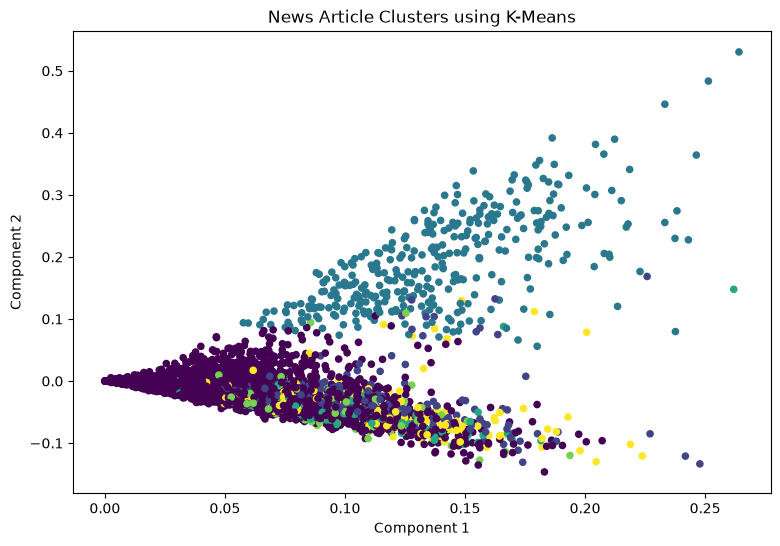

In [17]:
# Visualizing K-Means Clusters
svd = TruncatedSVD(
    n_components=2,
    random_state=42
)
reduced_data = svd.fit_transform(tfidf_matrix)
plt.figure(figsize=(9, 6))
plt.scatter(
    reduced_data[:, 0],
    reduced_data[:, 1],
    c=news_sample["KMeans_Cluster"],
    s=20
)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("News Article Clusters using K-Means")
plt.show()

In [18]:
# Hierarchical Clustering
hierarchical = AgglomerativeClustering(
    n_clusters=best_k
)
hierarchical_labels = hierarchical.fit_predict(
    tfidf_matrix.toarray()
)
news_sample["Hierarchical_Cluster"] = hierarchical_labels
news_sample[
    ["headline", "category", "Hierarchical_Cluster"]
].head(10)

,headline,category,Hierarchical_Cluster
0,What If We Were All Family Generation Changers?,IMPACT,0
1,Firestorm At AOL Over Employee Benefit Cuts,BUSINESS,0
2,Dakota Access Protesters Arrested As Deadline ...,POLITICS,0
3,One Glimpse Of These Baby Kit Foxes And You'll...,GREEN,0
4,"Mens' Sweat Pheromone, Androstadienone, Influe...",SCIENCE,0
5,Summer Sleepover Tips,PARENTING,0
6,End of the Year,WELLNESS,0
7,Maybe Colleges Should Take A Lesson From Zoos,SCIENCE,0
8,Supermodel Stephanie Seymour Does Sexy Photo S...,STYLE & BEAUTY,0
9,American Attitudes About Guns Have Become Much...,POLITICS,0


In [19]:
hierarchical_score = silhouette_score(
    tfidf_matrix,
    hierarchical_labels
)
print(
    "Hierarchical Clustering Silhouette Score:",
    round(hierarchical_score, 3)
)

Hierarchical Clustering Silhouette Score: -0.003


In [20]:
comparison = pd.DataFrame({
    "Technique": [
        "K-Means",
        "Hierarchical Clustering"
    ],
    "Silhouette Score": [
        kmeans_score,
        hierarchical_score
    ]
})
comparison

,Technique,Silhouette Score
0,K-Means,0.003553
1,Hierarchical Clustering,-0.003399


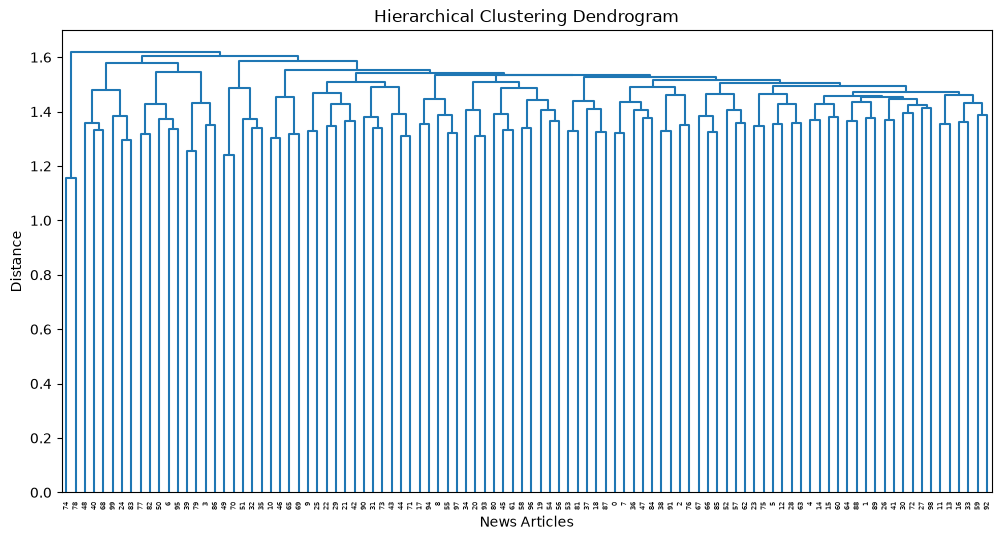

In [22]:
small_sample = tfidf_matrix[:100].toarray()
linked = linkage(
    small_sample,
    method="ward"
)
plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("News Articles")
plt.ylabel("Distance")
plt.show()

# Conclusion
- The News Category Dataset from Kaggle was used for the project.
- TF-IDF was used to convert news text into numerical features.
- K-Means clustering grouped similar news articles.
- Hierarchical clustering was also applied for comparison.
- Silhouette Score was used to evaluate the clustering quality.
- SVD was used to visualize the high-dimensional text clusters.
- The project demonstrates how unsupervised learning can automatically group similar news articles.